In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import re

In [21]:
df = pd.read_csv("crawled_data.csv")
df.head(20)

,Product:,Sale Date:,Category:,Quantity:,Total Price:,Total Profit:,Payment Type:,Customer Details:
0,White Tie and Shirt Set,01-01-2025,Men — Shirts,5,175.00,66.50,Credit Card,Cust ID: 7097\nFrom: Dublin\nGender: Female\nA...
1,Floral Embroidered Kaftan,2025-01-01,Children — Girls Clothing,1,32.00,16.32,Debit Card,Customer ID: 10753\nLocation Laois\nGender: F\...
2,Black Loose Fit Jeans,2025-01-02,Men — Jeans,1,29.00,11.60,Credit Card,ID 17356\nAge Category: 55—64\nCity: Mayo\nGen...
3,Dark Wash Straight Fit Jeans,2025-01-02,Men — Jeans,1,€ 33.00,€ 13.20,Credit Card,Age Range: 35-44\nGender: Male\nLocation: Lout...
4,Rose Print Prom Dress,2025-01-02,Children — Girls Clothing,1,€ 37.00,€ 18.87,Credit Card,ID: 12591\nCity: Dublin\nGender: Female\nAge G...
5,Orange/Navy Shorts Three Pack,2025-01-02,Children — Girls Clothing,2,EUR 33.00,EUR 16.83,Credit Card,Location Kerry\nCust ID: 7822\nGender: Female\...
6,Dark Wash Straight Fit Jeans,2025-01-03,Men — Jeans,-1,EUR 33.00,EUR 13.20,Debit Card,Customer ID: 18791\nCity: Dublin\nGender: Male...
7,Dawson Trolley,2025-01-03,Homeware — Design,1,€57.00,€22.80,Credit Card,Customer ID: 12619\nCity: Kildare\nGender: Fem...
8,Light Blue Ditsy Slub Dress,2025-01-03,Women — Dresses,1,20.25,9.00,Credit Card,Cust ID: 17834\nLocation: Laois\nGender: Male\...
9,Black Signature Point Court Shoes,03-01-2025,Men — Shoes,2,88.00,39.60,Debit Card,Cust ID: 1331\nLocation Dublin\nGender: Female...


# Preprocessing Data

## Remove header postfix

In [22]:
print("Before:", df.columns)
df.columns = df.columns.str.rstrip(':')
print("After:", df.columns)

Before: Index(['Product:', 'Sale Date:', 'Category:', 'Quantity:', 'Total Price:',
       'Total Profit:', 'Payment Type:', 'Customer Details:'],
      dtype='str')
After: Index(['Product', 'Sale Date', 'Category', 'Quantity', 'Total Price',
       'Total Profit', 'Payment Type', 'Customer Details'],
      dtype='str')


## Sale Dates

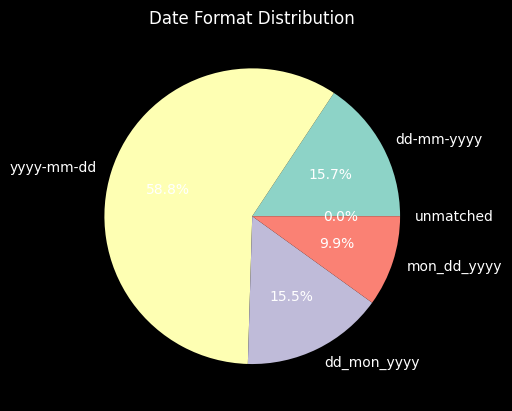

In [23]:
import functools
import operator

patterns = {
    "dd-mm-yyyy": r"^(0[1-9]|[12][0-9]|3[01])-(0[1-9]|1[0-2])-\d{4}$",
    "yyyy-mm-dd": r"^\d{4}-(0[1-9]|1[0-2])-(0[1-9]|[12][0-9]|3[01])$",
    "dd_mon_yyyy": r"^(0?[1-9]|[12][0-9]|3[01])\s(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)\s\d{4}$",
    "mon_dd_yyyy": r"^(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)\s(0?[1-9]|[12][0-9]|3[01]),\s\d{4}$"
}

total = len(df)

# build masks
masks = {
    name: df['Sale Date'].str.match(pattern, na=False)
    for name, pattern in patterns.items()
}

# percentages for known formats
percentages = {
    name: mask.mean() * 100
    for name, mask in masks.items()
}

# unmatched
any_match = functools.reduce(operator.or_, masks.values())
percentages["unmatched"] = (~any_match).mean() * 100

labels = percentages.keys()
sizes = percentages.values()

plt.figure()
plt.pie(sizes, labels=list(labels), autopct='%1.1f%%')
plt.title("Date Format Distribution")
plt.show()

In [24]:
df['Sale Date'] = pd.to_datetime(df['Sale Date'], errors='raise', format='mixed')
df.head(5)

,Product,Sale Date,Category,Quantity,Total Price,Total Profit,Payment Type,Customer Details
0,White Tie and Shirt Set,2025-01-01,Men — Shirts,5,175.00,66.50,Credit Card,Cust ID: 7097\nFrom: Dublin\nGender: Female\nA...
1,Floral Embroidered Kaftan,2025-01-01,Children — Girls Clothing,1,32.00,16.32,Debit Card,Customer ID: 10753\nLocation Laois\nGender: F\...
2,Black Loose Fit Jeans,2025-01-02,Men — Jeans,1,29.00,11.60,Credit Card,ID 17356\nAge Category: 55—64\nCity: Mayo\nGen...
3,Dark Wash Straight Fit Jeans,2025-01-02,Men — Jeans,1,€ 33.00,€ 13.20,Credit Card,Age Range: 35-44\nGender: Male\nLocation: Lout...
4,Rose Print Prom Dress,2025-01-02,Children — Girls Clothing,1,€ 37.00,€ 18.87,Credit Card,ID: 12591\nCity: Dublin\nGender: Female\nAge G...


## Category Column

In [25]:
pattern = r'\s*[—]\s*'

In [26]:
# Mask for rows that **match** the pattern
mask_match = df['Category'].str.contains(pattern, regex=True, na=False)

# Number of rows that **do NOT match**
num_unmatched = (~mask_match).sum()

print(f"Number of unmatched rows: {num_unmatched}")

Number of unmatched rows: 0


In [27]:
df[['Category_main', 'Category_sub']] = df['Category'].str.split(pattern, n=1, expand=True)
df['Category_main'] = df['Category_main'].str.strip()
df['Category_sub'] = df['Category_sub'].str.strip()

df.drop('Category', axis=1, inplace=True)
df.head(5)

,Product,Sale Date,Quantity,Total Price,Total Profit,Payment Type,Customer Details,Category_main,Category_sub
0,White Tie and Shirt Set,2025-01-01,5,175.00,66.50,Credit Card,Cust ID: 7097\nFrom: Dublin\nGender: Female\nA...,Men,Shirts
1,Floral Embroidered Kaftan,2025-01-01,1,32.00,16.32,Debit Card,Customer ID: 10753\nLocation Laois\nGender: F\...,Children,Girls Clothing
2,Black Loose Fit Jeans,2025-01-02,1,29.00,11.60,Credit Card,ID 17356\nAge Category: 55—64\nCity: Mayo\nGen...,Men,Jeans
3,Dark Wash Straight Fit Jeans,2025-01-02,1,€ 33.00,€ 13.20,Credit Card,Age Range: 35-44\nGender: Male\nLocation: Lout...,Men,Jeans
4,Rose Print Prom Dress,2025-01-02,1,€ 37.00,€ 18.87,Credit Card,ID: 12591\nCity: Dublin\nGender: Female\nAge G...,Children,Girls Clothing


## Quantity Column

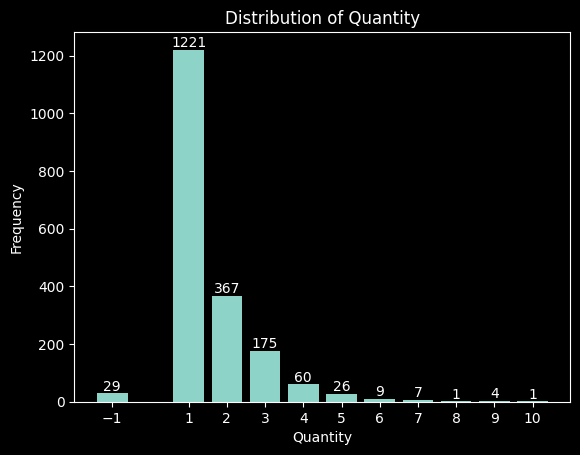

In [28]:
import matplotlib.pyplot as plt

counts = df['Quantity'].value_counts().sort_index()

bars = plt.bar(counts.index, counts.values)

plt.xlabel("Quantity")
plt.xticks(counts.index)
plt.ylabel("Frequency")
plt.title("Distribution of Quantity")

# add count labels on top
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        int(height),
        ha='center',
        va='bottom'
    )

plt.show()

## Total Price/Total Profit Column

In [29]:
df.head()

,Product,Sale Date,Quantity,Total Price,Total Profit,Payment Type,Customer Details,Category_main,Category_sub
0,White Tie and Shirt Set,2025-01-01,5,175.00,66.50,Credit Card,Cust ID: 7097\nFrom: Dublin\nGender: Female\nA...,Men,Shirts
1,Floral Embroidered Kaftan,2025-01-01,1,32.00,16.32,Debit Card,Customer ID: 10753\nLocation Laois\nGender: F\...,Children,Girls Clothing
2,Black Loose Fit Jeans,2025-01-02,1,29.00,11.60,Credit Card,ID 17356\nAge Category: 55—64\nCity: Mayo\nGen...,Men,Jeans
3,Dark Wash Straight Fit Jeans,2025-01-02,1,€ 33.00,€ 13.20,Credit Card,Age Range: 35-44\nGender: Male\nLocation: Lout...,Men,Jeans
4,Rose Print Prom Dress,2025-01-02,1,€ 37.00,€ 18.87,Credit Card,ID: 12591\nCity: Dublin\nGender: Female\nAge G...,Children,Girls Clothing


In [30]:
pattern = r'(€|EUR)'

df['Total Price'] = df['Total Price'].str.replace(pattern, '', regex=True).str.strip().astype(float)
df['Total Profit'] = df['Total Profit'].str.replace(pattern, '', regex=True).str.strip().astype(float)
df.head(20)

,Product,Sale Date,Quantity,Total Price,Total Profit,Payment Type,Customer Details,Category_main,Category_sub
0,White Tie and Shirt Set,2025-01-01,5,175.00,66.50,Credit Card,Cust ID: 7097\nFrom: Dublin\nGender: Female\nA...,Men,Shirts
1,Floral Embroidered Kaftan,2025-01-01,1,32.00,16.32,Debit Card,Customer ID: 10753\nLocation Laois\nGender: F\...,Children,Girls Clothing
2,Black Loose Fit Jeans,2025-01-02,1,29.00,11.60,Credit Card,ID 17356\nAge Category: 55—64\nCity: Mayo\nGen...,Men,Jeans
3,Dark Wash Straight Fit Jeans,2025-01-02,1,33.00,13.20,Credit Card,Age Range: 35-44\nGender: Male\nLocation: Lout...,Men,Jeans
4,Rose Print Prom Dress,2025-01-02,1,37.00,18.87,Credit Card,ID: 12591\nCity: Dublin\nGender: Female\nAge G...,Children,Girls Clothing
5,Orange/Navy Shorts Three Pack,2025-01-02,2,33.00,16.83,Credit Card,Location Kerry\nCust ID: 7822\nGender: Female\...,Children,Girls Clothing
6,Dark Wash Straight Fit Jeans,2025-01-03,-1,33.00,13.20,Debit Card,Customer ID: 18791\nCity: Dublin\nGender: Male...,Men,Jeans
7,Dawson Trolley,2025-01-03,1,57.00,22.80,Credit Card,Customer ID: 12619\nCity: Kildare\nGender: Fem...,Homeware,Design
8,Light Blue Ditsy Slub Dress,2025-01-03,1,20.25,9.00,Credit Card,Cust ID: 17834\nLocation: Laois\nGender: Male\...,Women,Dresses
9,Black Signature Point Court Shoes,2025-03-01,2,88.00,39.60,Debit Card,Cust ID: 1331\nLocation Dublin\nGender: Female...,Men,Shoes


## Payment Type Column

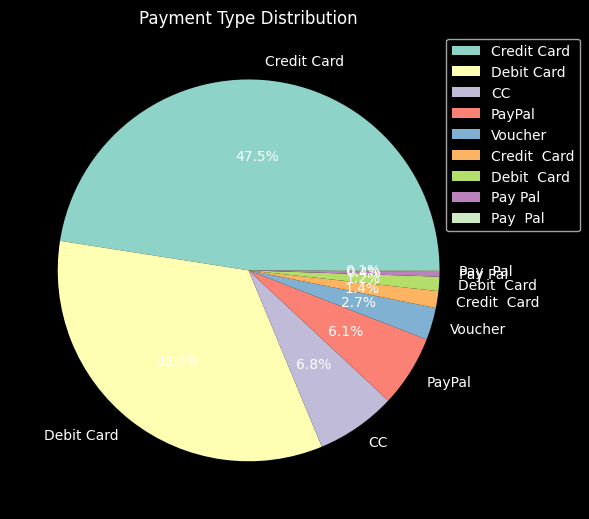

In [31]:
def visualize_payment_type_count(_df: pd.DataFrame):
    payment_types = _df['Payment Type'].value_counts()

    payment_types.plot.pie(
        autopct='%1.1f%%',
        figsize=(6,6),
        ylabel=''
    )

    plt.legend(payment_types.index, loc="upper left", bbox_to_anchor=(0.9, 1))

    plt.title("Payment Type Distribution")
    plt.tight_layout()

    plt.show()

visualize_payment_type_count(df)

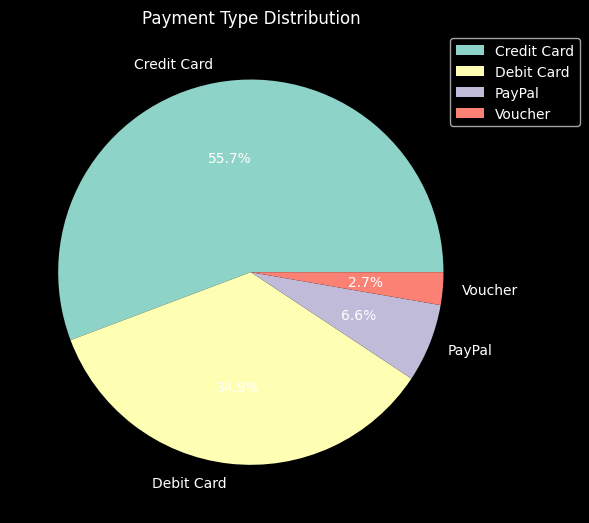

In [32]:
df['Payment Type'] = df['Payment Type'].str.replace(r'\s+', ' ', regex=True).str.strip()
df['Payment Type'] = df['Payment Type'].str.replace({"Pay Pal": "PayPal", "CC": "Credit Card"})

visualize_payment_type_count(df)

## Customer Detail Column

In [33]:
df["Customer Details"].head()

0    Cust ID: 7097\nFrom: Dublin\nGender: Female\nA...
1    Customer ID: 10753\nLocation Laois\nGender: F\...
2    ID 17356\nAge Category: 55—64\nCity: Mayo\nGen...
3    Age Range: 35-44\nGender: Male\nLocation: Lout...
4    ID: 12591\nCity: Dublin\nGender: Female\nAge G...
Name: Customer Details, dtype: str

In [34]:
def parse_customer_info_strict(info_str):
    # Define exception patterns and target columns inside the method
    exception_patterns = {
        r'^ID\s+(.+)$': 'ID',
        r'^Location\s+(.+)$': 'Location'
    }

    data_dict = {}
    for line in info_str.split('\n'):
        line = line.strip()
        if not line:
            continue

        matched = False
        # Check exceptions
        for pattern, col_name in exception_patterns.items():
            match = re.match(pattern, line)
            if match:
                data_dict[col_name] = match.group(1).strip()
                matched = True
                break
        if matched:
            continue

        # All other lines must be key: value
        if ':' in line:
            key, value = line.split(':', 1)
            data_dict[key.strip()] = value.strip()
        else:
            # Neither exception nor key:value → raise error
            raise ValueError(f"Invalid line format: '{line}'")


    return data_dict

customer_detail_df = (
    df['Customer Details']
    .apply(parse_customer_info_strict)
    .apply(pd.Series)
)

customer_detail_df.head(30)


,Cust ID,From,Gender,Age Range,Customer ID,Location,Age Group,ID,Age Category,City,Age
0,7097,Dublin,Female,25-34,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,F,NaN,10753,Laois,35—44,NaN,NaN,NaN,NaN
2,NaN,NaN,Male,NaN,NaN,NaN,NaN,17356,55—64,Mayo,NaN
3,NaN,NaN,Male,35-44,9750,Louth,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,Female,NaN,NaN,NaN,35-44,12591,NaN,Dublin,NaN
5,7822,NaN,Female,NaN,NaN,Kerry,45-54,NaN,NaN,NaN,NaN
6,NaN,NaN,Male,25-34,18791,NaN,NaN,NaN,NaN,Dublin,NaN
7,NaN,NaN,Female,18-24,12619,NaN,NaN,NaN,NaN,Kildare,NaN
8,17834,NaN,Male,NaN,NaN,Laois,NaN,NaN,35-44,NaN,NaN
9,1331,NaN,Female,25-34,NaN,Dublin,NaN,NaN,NaN,NaN,NaN


### Customer ID Column
Might be derived from one of there columns: `Cust ID`, `Customer ID` and `ID`
